In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv('User_Card.csv')
df1 = pd.read_csv('trans.csv')

In [3]:
df1.head()

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,NaN,No
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,No


In [4]:
df1.isnull().sum()

User                     0
Card                     0
Year                     0
Month                    0
Day                      0
Time                     0
Amount                   0
Use Chip                 0
Merchant Name            0
Merchant City            0
Merchant State     2720821
Zip                2878135
MCC                      0
Errors?           23998469
Is Fraud?                0
dtype: int64

In [5]:
df1.describe()

,User,Card,Year,Month,Day,Merchant Name,Zip,MCC
count,2.438690e+07,2.438690e+07,2.438690e+07,2.438690e+07,2.438690e+07,2.438690e+07,2.150876e+07,2.438690e+07
mean,1.001019e+03,1.351366e+00,2.011955e+03,6.525064e+00,1.571812e+01,-4.769230e+17,5.095644e+04,5.561171e+03
std,5.694612e+02,1.407154e+00,5.105921e+00,3.472355e+00,8.794073e+00,4.758940e+18,2.939707e+04,8.793154e+02
min,0.000000e+00,0.000000e+00,1.991000e+03,1.000000e+00,1.000000e+00,-9.222899e+18,5.010000e+02,1.711000e+03
25%,5.100000e+02,0.000000e+00,2.008000e+03,3.000000e+00,8.000000e+00,-4.500543e+18,2.837400e+04,5.300000e+03
50%,1.006000e+03,1.000000e+00,2.013000e+03,7.000000e+00,1.600000e+01,-7.946765e+17,4.674200e+04,5.499000e+03
75%,1.477000e+03,2.000000e+00,2.016000e+03,1.000000e+01,2.300000e+01,3.189517e+18,7.756400e+04,5.812000e+03
max,1.999000e+03,8.000000e+00,2.020000e+03,1.200000e+01,3.100000e+01,9.223292e+18,9.992800e+04,9.402000e+03


In [6]:
df1.describe(include = 'object')

,Time,Amount,Use Chip,Merchant City,Merchant State,Errors?,Is Fraud?
count,24386900,24386900,24386900,24386900,21666079,388431,24386900
unique,1440,98953,3,13429,223,23,2
top,12:31,$80.00,Swipe Transaction,ONLINE,CA,Insufficient Balance,No
freq,30604,250984,15386082,2720821,2591830,242783,24357143


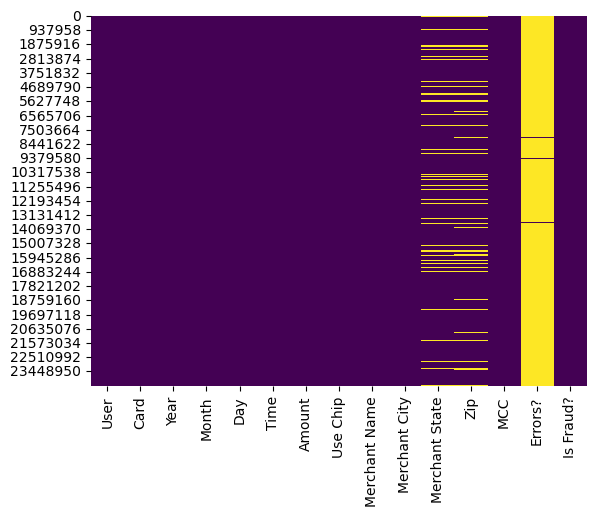

In [7]:
sns.heatmap(df1.isnull(),cbar = False , cmap = 'viridis' )
plt.show()

In [9]:
df1 = df1.drop(['Zip','Merchant State','Merchant Name'], axis = 1 )

In [10]:
df1.head()

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant City,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,La Verne,5300,NaN,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,Monterey Park,5411,NaN,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,Monterey Park,5411,NaN,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,Monterey Park,5651,NaN,No
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,La Verne,5912,NaN,No


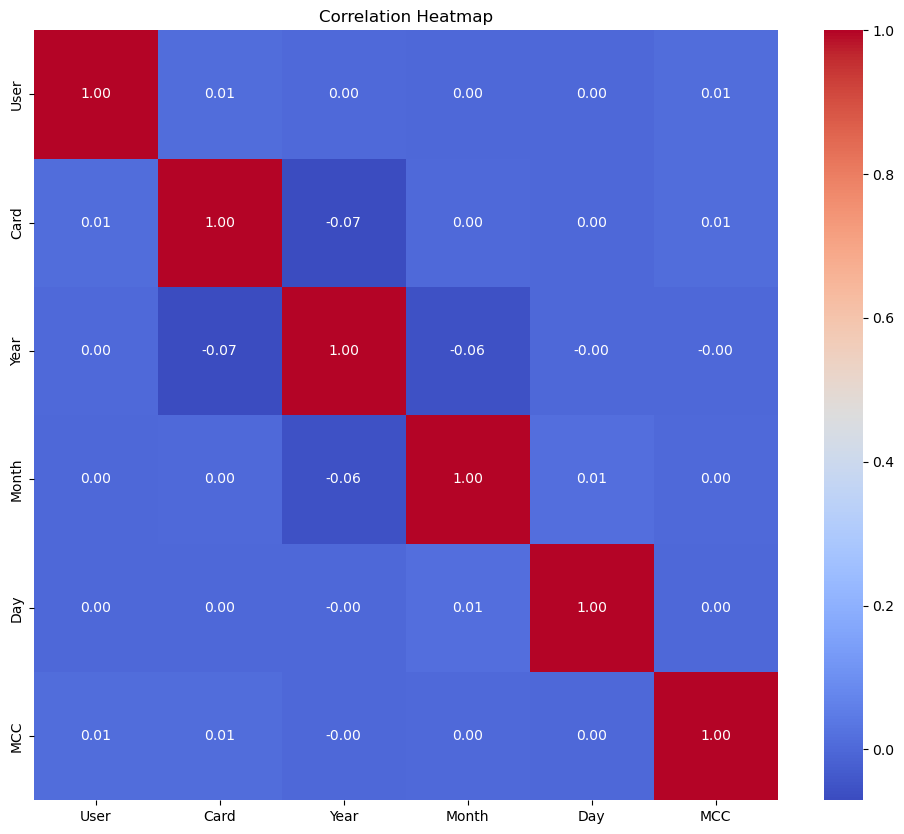

In [11]:
plt.figure(figsize=(12,10))
sns.heatmap(
    df1.select_dtypes(include='number').corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

In [12]:
df1 = df1.drop(['Merchant City' , 'Time'] , axis = 1)

In [13]:
df1.head()

,User,Card,Year,Month,Day,Amount,Use Chip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,$134.09,Swipe Transaction,5300,NaN,No
1,0,0,2002,9,1,$38.48,Swipe Transaction,5411,NaN,No
2,0,0,2002,9,2,$120.34,Swipe Transaction,5411,NaN,No
3,0,0,2002,9,2,$128.95,Swipe Transaction,5651,NaN,No
4,0,0,2002,9,3,$104.71,Swipe Transaction,5912,NaN,No


In [14]:
df1['Errors?'].unique()

array([nan, 'Technical Glitch', 'Insufficient Balance', 'Bad PIN',
       'Bad PIN,Insufficient Balance', 'Bad Expiration',
       'Bad PIN,Technical Glitch', 'Bad Card Number', 'Bad CVV',
       'Bad Zipcode', 'Insufficient Balance,Technical Glitch',
       'Bad Card Number,Insufficient Balance', 'Bad Card Number,Bad CVV',
       'Bad CVV,Insufficient Balance', 'Bad Card Number,Bad Expiration',
       'Bad Expiration,Bad CVV', 'Bad Expiration,Insufficient Balance',
       'Bad Expiration,Technical Glitch',
       'Bad Card Number,Bad Expiration,Technical Glitch',
       'Bad CVV,Technical Glitch', 'Bad Card Number,Technical Glitch',
       'Bad Zipcode,Insufficient Balance', 'Bad Zipcode,Technical Glitch',
       'Bad Card Number,Bad Expiration,Insufficient Balance'],
      dtype=object)

In [15]:
df1['Errors?'].value_counts()

Errors?
Insufficient Balance                                   242783
Bad PIN                                                 58918
Technical Glitch                                        48157
Bad Card Number                                         13321
Bad CVV                                                 10740
Bad Expiration                                          10716
Bad Zipcode                                              2079
Bad PIN,Insufficient Balance                              581
Insufficient Balance,Technical Glitch                     457
Bad PIN,Technical Glitch                                  128
Bad Card Number,Insufficient Balance                      122
Bad CVV,Insufficient Balance                               89
Bad Expiration,Insufficient Balance                        78
Bad Card Number,Bad CVV                                    60
Bad Card Number,Bad Expiration                             54
Bad Expiration,Bad CVV                                     47


In [19]:
df1 = df1.fillna('No Error')

In [20]:
df1['Errors?'].value_counts()

Errors?
No Error                                               23998469
Insufficient Balance                                     242783
Bad PIN                                                   58918
Technical Glitch                                          48157
Bad Card Number                                           13321
Bad CVV                                                   10740
Bad Expiration                                            10716
Bad Zipcode                                                2079
Bad PIN,Insufficient Balance                                581
Insufficient Balance,Technical Glitch                       457
Bad PIN,Technical Glitch                                    128
Bad Card Number,Insufficient Balance                        122
Bad CVV,Insufficient Balance                                 89
Bad Expiration,Insufficient Balance                          78
Bad Card Number,Bad CVV                                      60
Bad Card Number,Bad Expiration  

In [21]:
df1.head()

,User,Card,Year,Month,Day,Amount,Use Chip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,$134.09,Swipe Transaction,5300,No Error,No
1,0,0,2002,9,1,$38.48,Swipe Transaction,5411,No Error,No
2,0,0,2002,9,2,$120.34,Swipe Transaction,5411,No Error,No
3,0,0,2002,9,2,$128.95,Swipe Transaction,5651,No Error,No
4,0,0,2002,9,3,$104.71,Swipe Transaction,5912,No Error,No


In [23]:

columns_to_clean = ['Amount']


existing_columns = [col for col in columns_to_clean if col in df1.columns]


for col in existing_columns:
    df1[col] = df1[col].replace('[\$,]', '', regex=True).astype(float)


df1[existing_columns].head()

,Amount
0,134.09
1,38.48
2,120.34
3,128.95
4,104.71


In [24]:
df1.head()

,User,Card,Year,Month,Day,Amount,Use Chip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,134.09,Swipe Transaction,5300,No Error,No
1,0,0,2002,9,1,38.48,Swipe Transaction,5411,No Error,No
2,0,0,2002,9,2,120.34,Swipe Transaction,5411,No Error,No
3,0,0,2002,9,2,128.95,Swipe Transaction,5651,No Error,No
4,0,0,2002,9,3,104.71,Swipe Transaction,5912,No Error,No


In [25]:
df1['Use Chip'].unique()

array(['Swipe Transaction', 'Online Transaction', 'Chip Transaction'],
      dtype=object)

/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_56434/2990445740.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tx_counts, x='Transaction Type', y='Count', palette='Set2')


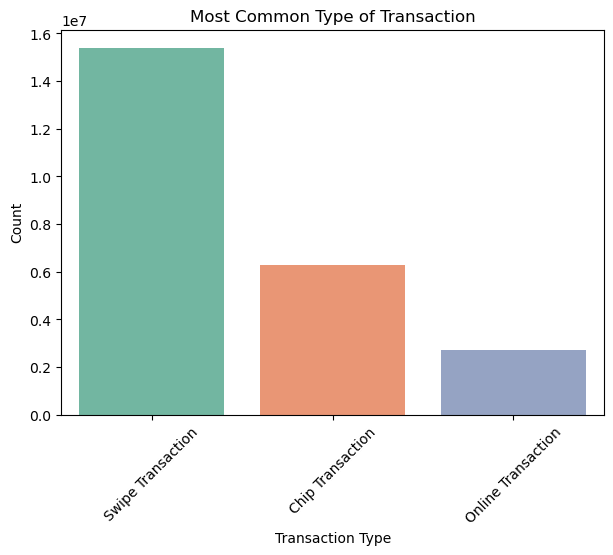

In [28]:
# Count of each transaction type
tx_counts = df1['Use Chip'].value_counts().reset_index()

# Rename the columns properly
tx_counts.columns = ['Transaction Type', 'Count']

# Plot
plt.figure(figsize=(7,5))
sns.barplot(data=tx_counts, x='Transaction Type', y='Count', palette='Set2')
plt.title('Most Common Type of Transaction')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_56434/1892410621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_years.index, y=top_years.values, palette='viridis')


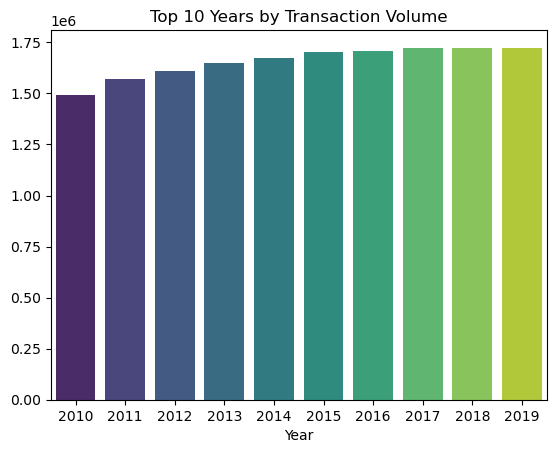

In [32]:
# Show only top 10 years with most transactions
top_years = year_counts.nlargest(10)
sns.barplot(x=top_years.index, y=top_years.values, palette='viridis')
plt.title('Top 10 Years by Transaction Volume')
plt.show()



/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_56434/3186850169.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='Reds_r')


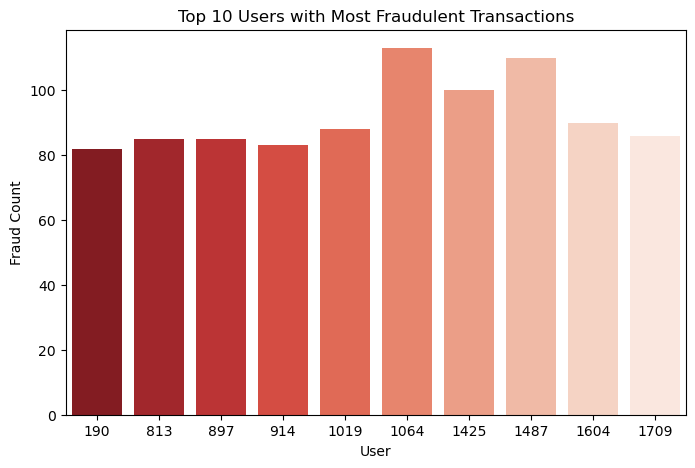

In [33]:
# 3️⃣ User with most fraudulent transactions
fraud_counts = df1[df1['Is Fraud?'] == 'Yes']['User'].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='Reds_r')
plt.title('Top 10 Users with Most Fraudulent Transactions')
plt.xlabel('User')
plt.ylabel('Fraud Count')
plt.show()


/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_56434/1816174245.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=err_counts.index, y=err_counts.values, palette='mako')


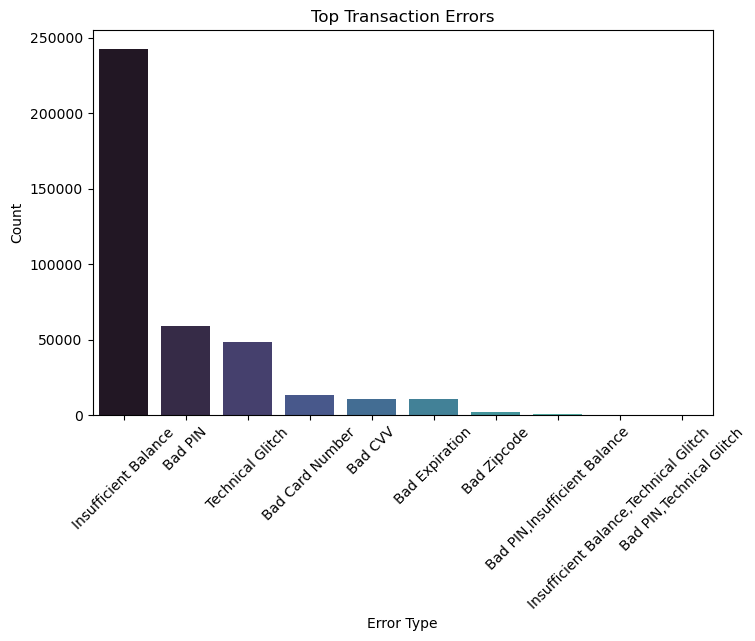

In [34]:
# 4️⃣ Most common error type
err_counts = df1[df1['Errors?'] != 'No Error']['Errors?'].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=err_counts.index, y=err_counts.values, palette='mako')
plt.title('Top Transaction Errors')
plt.xlabel('Error Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_56434/3166453032.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=user_spend.index, y=user_spend.values, palette='viridis')


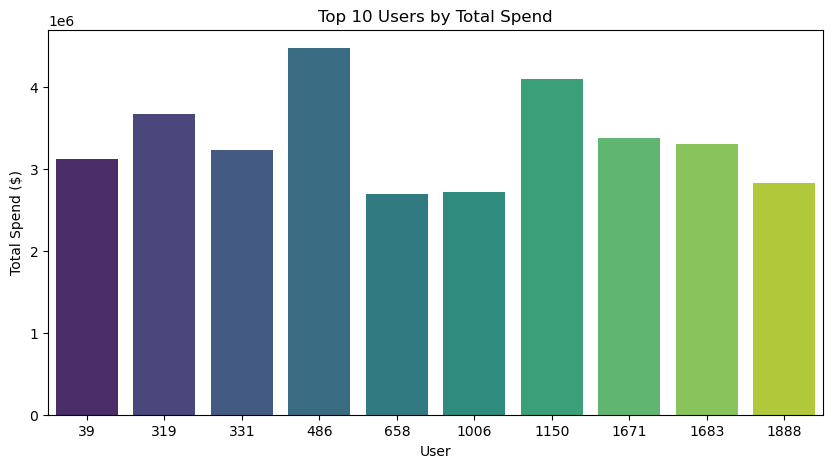

In [36]:
# 5️⃣ User with highest total spend
user_spend = df1.groupby('User')['Amount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=user_spend.index, y=user_spend.values, palette='viridis')
plt.title('Top 10 Users by Total Spend')
plt.xlabel('User')
plt.ylabel('Total Spend ($)')
plt.show()


/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_56434/1470538586.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mcc_counts.index.astype(str), y=mcc_counts.values, palette='crest')


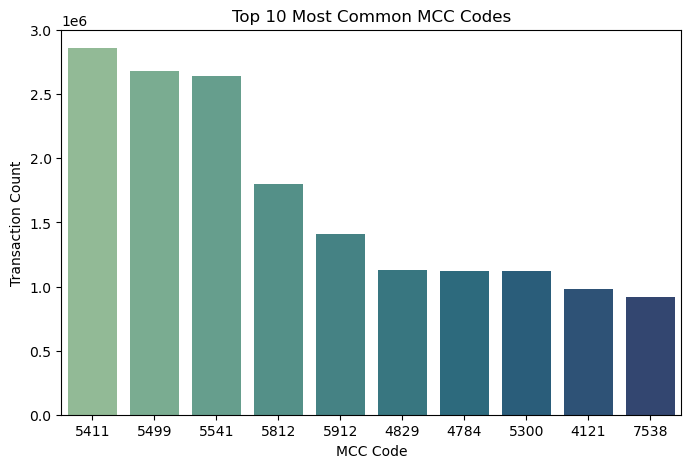

In [37]:
# 6️⃣ Most common MCC
mcc_counts = df1['MCC'].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=mcc_counts.index.astype(str), y=mcc_counts.values, palette='crest')
plt.title('Top 10 Most Common MCC Codes')
plt.xlabel('MCC Code')
plt.ylabel('Transaction Count')
plt.show()

In [40]:
# Group by Error type and Fraud status
error_fraud_summary = (
    df1.groupby(['Errors?', 'Is Fraud?'])
    .size()
    .reset_index(name='Count')
    .sort_values(by='Count', ascending=False)
)

display(error_fraud_summary.head(10))


,Errors?,Is Fraud?,Count
35,No Error,No,23969998
32,Insufficient Balance,No,242387
23,Bad PIN,No,58616
37,Technical Glitch,No,48094
36,No Error,Yes,28471
6,Bad Card Number,No,13216
15,Bad Expiration,No,10596
0,Bad CVV,No,10460
29,Bad Zipcode,No,2079
25,"Bad PIN,Insufficient Balance",No,574


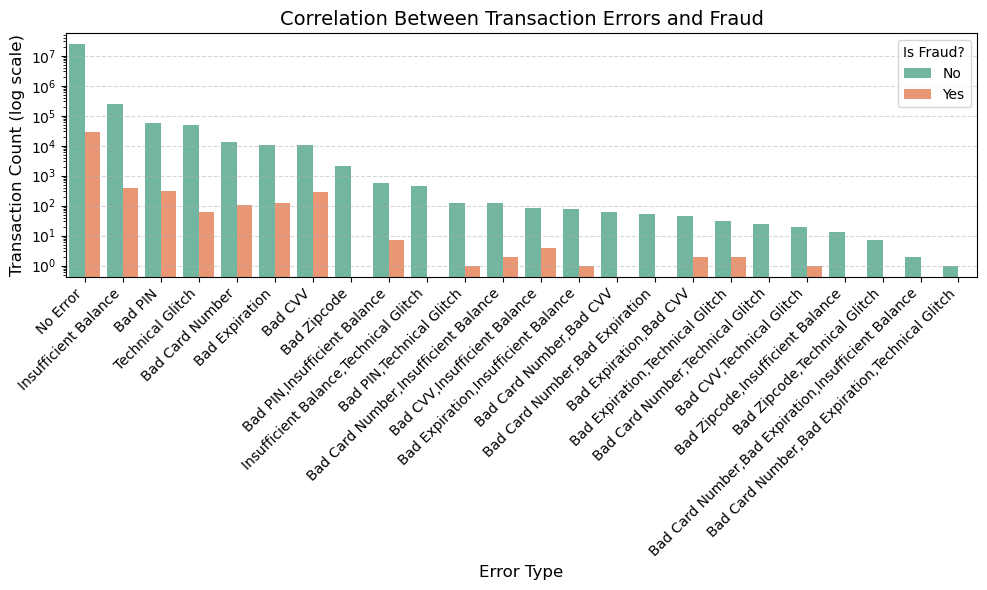

In [41]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=error_fraud_summary,
    x='Errors?', 
    y='Count', 
    hue='Is Fraud?', 
    palette='Set2'
)

plt.title('Correlation Between Transaction Errors and Fraud', fontsize=14)
plt.xlabel('Error Type', fontsize=12)
plt.ylabel('Transaction Count (log scale)', fontsize=12)
plt.yscale('log')  # helps with large data spread
plt.xticks(rotation=45, ha='right')
plt.legend(title='Is Fraud?')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [42]:
# Group by Use Chip and Fraud
usechip_fraud_summary = (
    df1.groupby(['Use Chip', 'Is Fraud?'])
    .size()
    .reset_index(name='Count')
    .sort_values(by='Count', ascending=False)
)

display(usechip_fraud_summary.head())


,Use Chip,Is Fraud?,Count
4,Swipe Transaction,No,15379510
0,Chip Transaction,No,6282762
2,Online Transaction,No,2694871
3,Online Transaction,Yes,18349
5,Swipe Transaction,Yes,6572


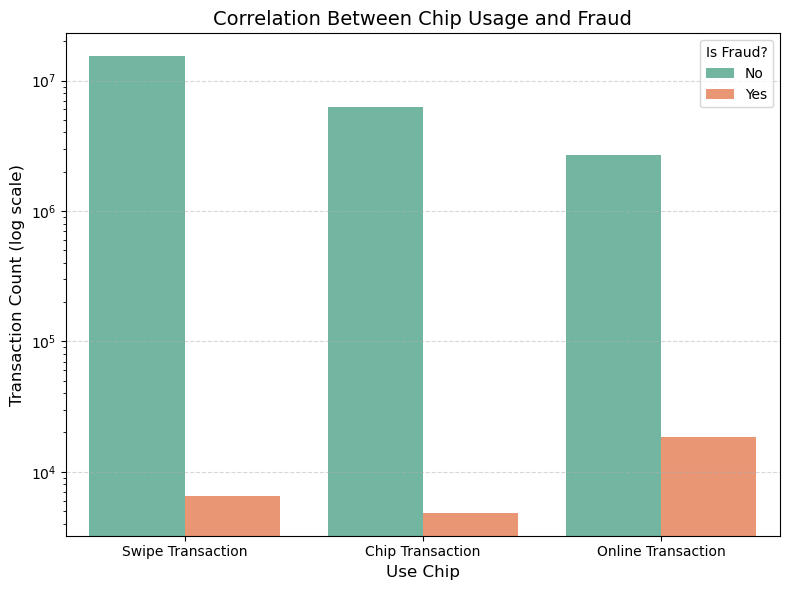

In [43]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=usechip_fraud_summary,
    x='Use Chip',
    y='Count',
    hue='Is Fraud?',
    palette='Set2'
)

plt.title('Correlation Between Chip Usage and Fraud', fontsize=14)
plt.xlabel('Use Chip', fontsize=12)
plt.ylabel('Transaction Count (log scale)', fontsize=12)
plt.yscale('log')  # handles imbalance
plt.legend(title='Is Fraud?')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_56434/494339297.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_amount, x='Is Fraud?', y='Amount', palette='coolwarm')


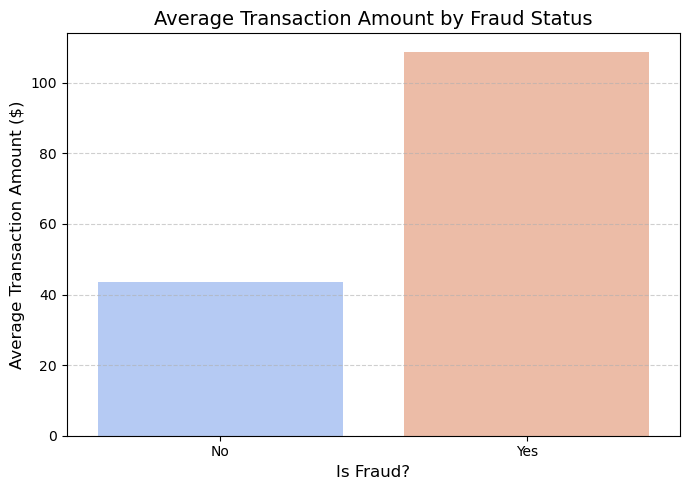

In [44]:
avg_amount = df1.groupby('Is Fraud?')['Amount'].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(data=avg_amount, x='Is Fraud?', y='Amount', palette='coolwarm')
plt.title('Average Transaction Amount by Fraud Status', fontsize=14)
plt.xlabel('Is Fraud?', fontsize=12)
plt.ylabel('Average Transaction Amount ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_56434/2539165245.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(
/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_56434/2539165245.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(


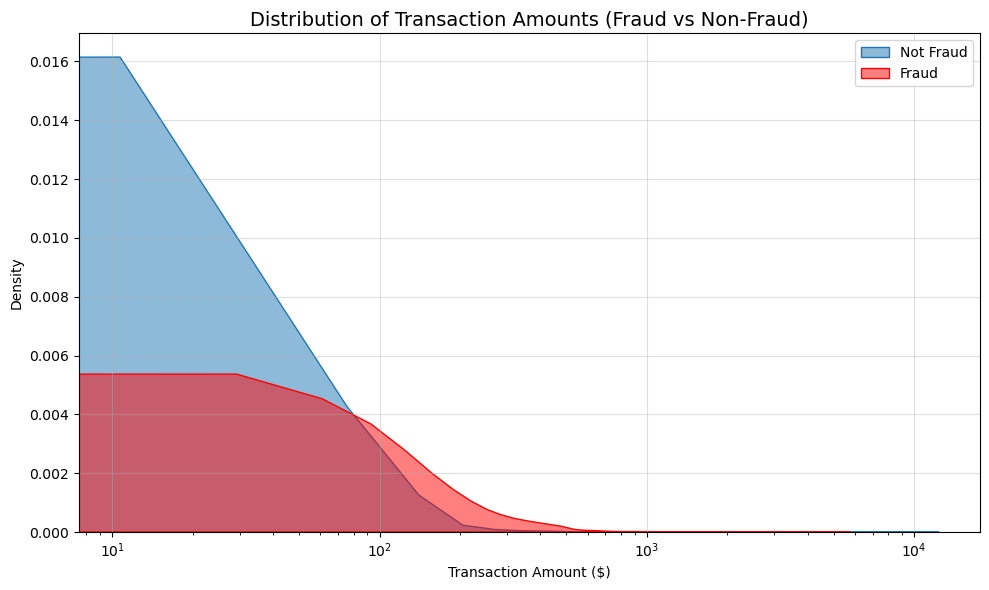

In [45]:
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df1[df1['Is Fraud?'] == 'No']['Amount'],
    label='Not Fraud',
    shade=True,
    alpha=0.5
)
sns.kdeplot(
    data=df1[df1['Is Fraud?'] == 'Yes']['Amount'],
    label='Fraud',
    shade=True,
    alpha=0.5,
    color='red'
)
plt.title('Distribution of Transaction Amounts (Fraud vs Non-Fraud)', fontsize=14)
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Density')
plt.legend()
plt.xscale('log')  # use log-scale to handle extreme values
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


In [47]:
# Count the number of transactions per user
user_tx_counts = df1['User'].value_counts().reset_index()

# Rename columns for clarity
user_tx_counts.columns = ['User', 'Transaction_Count']

# Sort descending (most active users on top)
user_tx_counts = user_tx_counts.sort_values(by='Transaction_Count', ascending=False).reset_index(drop=True)

# Display top 10 users
user_tx_counts.head(2000)


,User,Transaction_Count
0,486,82355
1,396,80749
2,332,70010
3,262,68089
4,1249,65644
...,...,...
1995,457,25
1996,231,21
1997,1367,20
1998,1767,16


In [48]:
# Filter only fraudulent transactions
fraud_df = df1[df1['Is Fraud?'].str.lower() == 'yes']

# Count fraudulent transactions per user
fraud_counts = fraud_df['User'].value_counts().reset_index()

# Rename columns for clarity
fraud_counts.columns = ['User', 'Fraudulent_Transaction_Count']

# Sort descending
fraud_counts = fraud_counts.sort_values(by='Fraudulent_Transaction_Count', ascending=False).reset_index(drop=True)

# Display top 10 users with most frauds
fraud_counts.head(10)


,User,Fraudulent_Transaction_Count
0,1064,113
1,1487,110
2,1425,100
3,1604,90
4,1019,88
5,1709,86
6,813,85
7,897,85
8,914,83
9,190,82


/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_56434/41227432.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


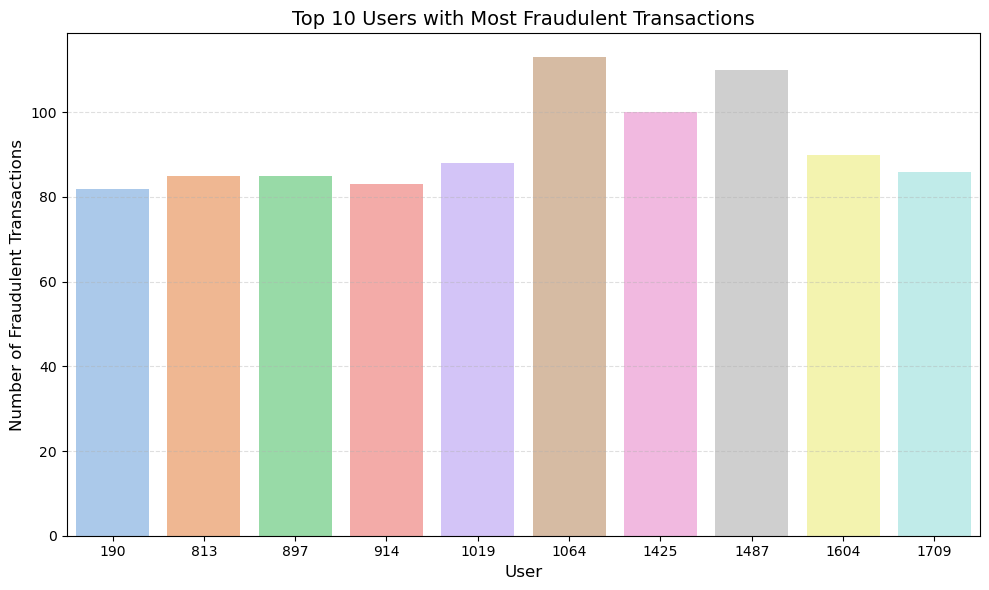

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Take top 10 users from fraud_counts
top_fraud_users = fraud_counts.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_fraud_users,
    x='User',
    y='Fraudulent_Transaction_Count',
    palette='pastel'  # softer colors
)

plt.title('Top 10 Users with Most Fraudulent Transactions', fontsize=14)
plt.xlabel('User', fontsize=12)
plt.ylabel('Number of Fraudulent Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_56434/3804569859.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x='Is Fraud?', y='Amount', palette='pastel')


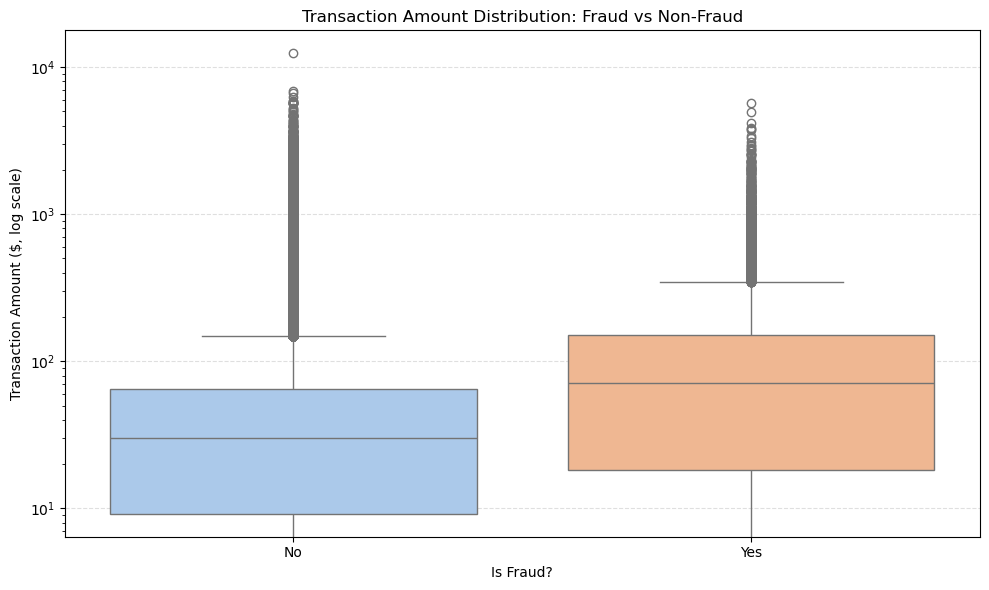

In [50]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df1, x='Is Fraud?', y='Amount', palette='pastel')
plt.yscale('log')  # handle extreme values
plt.title('Transaction Amount Distribution: Fraud vs Non-Fraud')
plt.xlabel('Is Fraud?')
plt.ylabel('Transaction Amount ($, log scale)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


/var/folders/s4/m8r6vx7j7873dljxvwf3ts9r0000gn/T/ipykernel_56434/3546999924.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_mcc_fraud.index, y=top_mcc_fraud.values, palette='pastel')


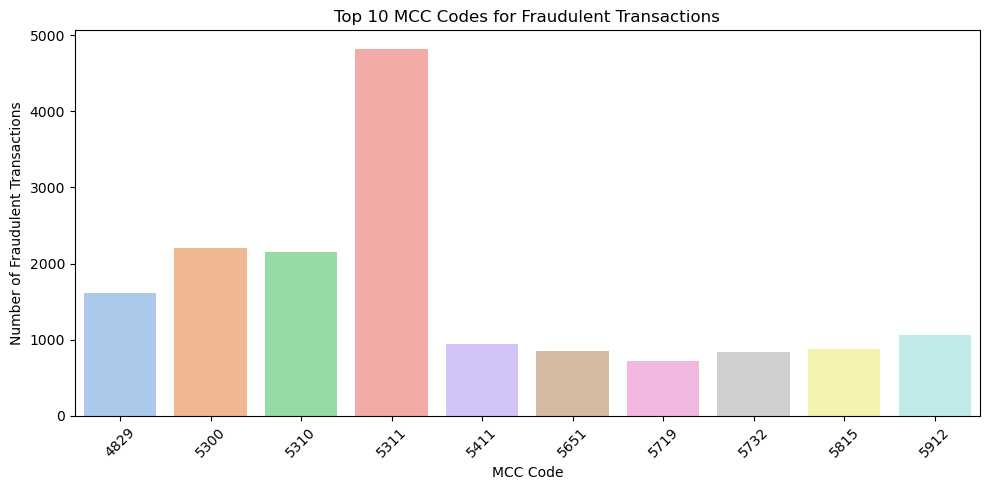

In [51]:
top_mcc_fraud = df1[df1['Is Fraud?'] == 'Yes']['MCC'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_mcc_fraud.index, y=top_mcc_fraud.values, palette='pastel')
plt.title('Top 10 MCC Codes for Fraudulent Transactions')
plt.xlabel('MCC Code')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [52]:
df1.head()

,User,Card,Year,Month,Day,Amount,Use Chip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,134.09,Swipe Transaction,5300,No Error,No
1,0,0,2002,9,1,38.48,Swipe Transaction,5411,No Error,No
2,0,0,2002,9,2,120.34,Swipe Transaction,5411,No Error,No
3,0,0,2002,9,2,128.95,Swipe Transaction,5651,No Error,No
4,0,0,2002,9,3,104.71,Swipe Transaction,5912,No Error,No


In [53]:
df1.to_csv('trans_cleaned.csv',index = False)
print("Cleaned Trans data")

Cleaned Trans data
